# Stress test: sampling time vs $n$

Expressions: $e_{\mathrm{ex1}}$, $e_{\mathrm{ex2}}$, $e_{\mathrm{ex3}}$, $e_{\mathrm{exb}}$.  
Hard budget: **20 min per expression**. Mean wall-clock time shown; no scatter.

In [8]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import sys, os, time, random
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def _find_repo_root():
    try:
        d = os.path.abspath(os.getcwd())
    except (FileNotFoundError, OSError):
        d = '/workspace'
    while True:
        if os.path.isfile(os.path.join(d, 'parse', 'quickparse.py')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError('Could not find repo root')
        d = parent

REPO = _find_repo_root()
PAPER_EXP = os.path.join(REPO, 'experiments', 'paper_experiments')
for p in [REPO, PAPER_EXP]:
    if p not in sys.path: sys.path.insert(0, p)

from parse.quickparse import quickparse
from sample.sample import sample
from volume.slice_volume import slice_volume
from volume.VolumePoly import continuous_convolution
from sympy.core.cache import clear_cache as clear_sympy_cache
from plot_config import *
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": [],
    "font.weight": "normal",
})

random.seed(42); np.random.seed(42)

phi_test = quickparse('<a>_[0,1] *', string=True)
w = sample(phi_test, 3)
print('VolTRE OK:', w)


VolTRE OK: (0.389, a),(0.816, a),(0.485, a)


In [9]:
import matplotlib.pyplot as plt

phi_ex1 = quickparse('<a>_[0,1] *', string=True)
# phi_ex2 = quickparse('a * . <a . a>_[0,1] . a *', string=True)  # old ex2
phi_ex2 = quickparse('a*.<a*>_[1,2]', string=True)  # new eex2 (Example 9 / theorem4)
phi_ex3 = quickparse('(<a . a>_[0,1] . a) & (a . <a . a>_[0,1])', string=True)
phi_exb = quickparse('<b>_[3,4] * . (<a>_[1,2] . <b>_[3,4] . <b>_[3,4] *) *', string=True)

K        = 20
BUDGET_S = 1200
RESULTS  = os.path.join(REPO, 'experiments', 'paper_experiments', '11_stress_test', 'results')
os.makedirs(RESULTS, exist_ok=True)

FIG_W   = fig_width_in
COL_W   = fig_width_in / 2
PANEL_H = 1.9

COLORS = {
    'volume':        '#F7B7A3',
    'sample':        '#A8D5BA',
    'smart_rej':     '#FDDFA9',
    'intersect_rej': '#C6B8E3',
}

import csv

def save_results_csv(path, xs, results):
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['xval', 't_vol', 't_sample', 'avg_smart_rej', 'avg_intersect_rej', 'n_fail'])
        for xval in xs:
            if xval in results:
                r = results[xval]
                w.writerow([xval, r['t_vol'], r['t_sample'],
                            r['avg_smart_rej'], r['avg_intersect_rej'], r['n_fail']])

def load_results_csv(path):
    xs, results = [], {}
    with open(path, newline='') as f:
        for row in csv.DictReader(f):
            xval = float(row['xval'])
            xs.append(xval)
            results[xval] = {
                't_vol':             float(row['t_vol']),
                't_sample':          float(row['t_sample']),
                'avg_smart_rej':     float(row['avg_smart_rej']),
                'avg_intersect_rej': float(row['avg_intersect_rej']),
                'n_fail':            int(row['n_fail']),
            }
    return xs, results


def collect_timed(phi, xs, n_of, T_of, label, is_intersection=False):
    results = {}
    t_start = time.perf_counter()
    print(f"=== {label} ===")
    for xval in xs:
        elapsed = time.perf_counter() - t_start
        if elapsed > BUDGET_S:
            print(f"  budget hit after {elapsed:.0f}s, stopping")
            break
        n = n_of(xval)
        T = T_of(xval)
        print(f"  n={n}  T={T}  elapsed={elapsed:.0f}s", flush=True)
        slice_volume.cache_clear()
        continuous_convolution.cache_clear()
        clear_sympy_cache()
        if is_intersection:
            # Intersection raises in slice_volume at the top level, but volumes ARE
            # computed for both arms inside each sample() call.  Precompute them here
            # on the original (non-renamed) children — same structure, same cost — so
            # the bar chart shows the real init cost instead of hiding it in t_sample.
            # Note: sample() re-parses a renamed copy of child0 each call (lru_cache
            # misses across K calls), so t_sample still includes a small per-call
            # volume overhead, but it is negligible compared to rejection time.
            t0 = time.perf_counter()
            try:
                child0, child1 = phi.expr(0), phi.expr(1)
                for k in range(n + 1):
                    slice_volume(child0, k)
                    slice_volume(child1, k)
                t_vol = time.perf_counter() - t0
            except Exception as e:
                print(f"    sub-volume precompute failed: {type(e).__name__}, skipping")
                t_vol = 0.0
        else:
            t0 = time.perf_counter()
            try:
                slice_volume(phi, n)
                t_vol = time.perf_counter() - t0
            except Exception as e:
                print(f"    slice_volume failed: {type(e).__name__}, skipping")
                continue
        total_sr, total_ir, n_ok = 0, 0, 0
        t0 = time.perf_counter()
        for _ in range(K):
            try:
                kw = {'n': n, 'feedback': True}
                if T is not None:
                    kw['T'] = T
                _, fb = sample(phi, **kw)
                total_sr += fb.smart_rej
                if fb.intersect_rej is not None:
                    total_ir += fb.intersect_rej
                n_ok += 1
            except Exception:
                pass
        t_sample_total = time.perf_counter() - t0
        n_fail = K - n_ok
        if n_ok > 0:
            t_sper = t_sample_total / n_ok
            results[xval] = {
                't_vol': t_vol, 't_sample': t_sper,
                'avg_smart_rej': total_sr / n_ok,
                'avg_intersect_rej': total_ir / n_ok,
                'n_fail': n_fail}
            print(f"    t_vol={t_vol:.2f}s  t_sample/call={t_sper:.3f}s  "
                  f"s_rej={total_sr/n_ok:.1f}  i_rej={total_ir/n_ok:.1f}  "
                  f"ok={n_ok}/{K}")
        else:
            results[xval] = {
                't_vol': t_vol, 't_sample': 0,
                'avg_smart_rej': 0, 'avg_intersect_rej': 0, 'n_fail': K}
            print(f"    all {K} samples failed  t_vol={t_vol:.2f}s")
    return results


def stress_bar_plot(ax, xs, results, xlabel, title):
    xs_plotted = [x for x in xs if x in results]
    if not xs_plotted:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        return
    has_vol       = any(results[v]['t_vol']             > 0    for v in xs_plotted)
    has_smart     = any(results[v]['avg_smart_rej']     > 0.05 for v in xs_plotted)
    has_intersect = any(results[v]['avg_intersect_rej'] > 0.05 for v in xs_plotted)
    xpos = np.arange(len(xs_plotted))
    t_vols, t_nets, t_srejs, t_irejs = [], [], [], []
    for v in xs_plotted:
        tv = results[v]['t_vol']
        ts = results[v]['t_sample']
        sr = results[v]['avg_smart_rej']
        ir = results[v]['avg_intersect_rej']
        t_net = ts / (1 + sr) if sr > 0 else ts
        t_vols.append(tv)
        t_nets.append(t_net)
        t_srejs.append(ts - t_net)
        t_irejs.append(ir * t_net)
    t_totals  = [tv + tn + tsr + tir
                 for tv, tn, tsr, tir in zip(t_vols, t_nets, t_srejs, t_irejs)]
    max_total = max(t_totals) if t_totals else 1
    bottom = np.zeros(len(xs_plotted))
    if has_vol:
        ax.bar(xpos, t_vols, color=COLORS['volume'], label='volume computation (init.)', width=0.7)
        bottom += np.array(t_vols)
    ax.bar(xpos, t_nets, color=COLORS['sample'], label='time per sample', bottom=bottom, width=0.7)
    bottom += np.array(t_nets)
    if has_smart:
        ax.bar(xpos, t_srejs, color=COLORS['smart_rej'],
               label='ambiguity rejection time (per sample)', bottom=bottom, width=0.7)
        bottom += np.array(t_srejs)
    if has_intersect:
        ax.bar(xpos, t_irejs, color=COLORS['intersect_rej'],
               label='intersection rejection time (per sample)', bottom=bottom, width=0.7)
    for i, (t, v) in enumerate(zip(t_totals, xs_plotted)):
        nf    = results[v].get('n_fail', 0)
        color = '#d62728' if nf == K else '#333'
        lbl   = f'{t:.1f}s*' if nf else f'{t:.1f}s'
        ax.text(xpos[i], t + max_total * 0.025, lbl,
                ha='center', va='bottom', fontsize=5.5, color=color)
    all_fail_xs = [x for x in xs if x not in results or results[x]['n_fail'] == K]
    if all_fail_xs and xs_plotted:
        ax.axvline(x=xpos[-1] + 0.5, color='#d62728', linestyle='--', lw=0.8, alpha=0.7)
        ax.text(xpos[-1] + 0.55, max_total * 0.65,
                f'$\\geq {all_fail_xs[0]}$:\\nall fail',
                color='#d62728', fontsize=5.5, ha='left', va='top')
    rot = 45 if len(xs_plotted) > 9 else 0
    ax.set_xticks(xpos)
    ax.set_xticklabels([str(v) for v in xs_plotted],
                       fontsize=6, rotation=rot, ha='right' if rot else 'center')
    ax.set_ylim(0, max_total * 1.55)
    ax.set_xlabel(xlabel, fontsize=7, labelpad=2)
    ax.set_ylabel('time (s)', fontsize=7)
    ax.set_title(title, fontsize=7.5)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    h, lab = ax.get_legend_handles_labels()
    if h:
        ax.legend(h, lab, loc='upper left', ncol=1, frameon=True,
                  handlelength=0.8, fontsize=5.5, borderpad=0.3, labelspacing=0.2)


print(f"Config ready.  K={K}  budget={BUDGET_S}s  COL_W={COL_W:.2f}in")

Config ready.  K=20  budget=1200s  COL_W=2.89in


## $e_{\mathrm{ex1}} = (\langle a\rangle_{\leq 1})^*$

Time grows slowly; at $n\geq 22$ **all samples fail** (mpmath precision in inverse CDF).

=== ex1 ===
  n=3  T=None  elapsed=0s
    t_vol=0.01s  t_sample/call=0.017s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=6  T=None  elapsed=0s
    t_vol=0.09s  t_sample/call=0.069s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=9  T=None  elapsed=2s
    t_vol=0.35s  t_sample/call=0.143s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=12  T=None  elapsed=5s
    t_vol=1.15s  t_sample/call=0.355s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=15  T=None  elapsed=13s
    t_vol=2.89s  t_sample/call=0.600s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=18  T=None  elapsed=28s
    t_vol=5.82s  t_sample/call=0.935s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=21  T=None  elapsed=53s
    t_vol=10.57s  t_sample/call=1.539s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=24  T=None  elapsed=94s
    t_vol=18.87s  t_sample/call=2.279s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=27  T=None  elapsed=159s
    t_vol=33.26s  t_sample/call=3.148s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=30  T=None  elapsed=255s
    t_vol=50.62s  t_sample/call=4.366s  s_rej=0.0  i_rej=0.0  ok=20/20


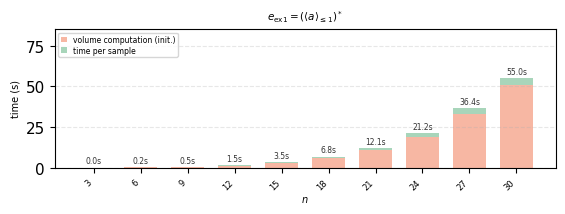

In [10]:
import random
random.seed(42); np.random.seed(42)

LOAD_EX1     = False  # set True to skip sampling and load saved CSV
N_VALUES_EX1 = list(range(3, 31, 3))  # [3,6,...,30], step 3
CSV_EX1      = os.path.join(RESULTS, 'results_ex1.csv')

if LOAD_EX1 and os.path.exists(CSV_EX1):
    N_VALUES_EX1, results_ex1 = load_results_csv(CSV_EX1)
    N_VALUES_EX1 = [int(v) for v in N_VALUES_EX1]
else:
    results_ex1 = collect_timed(
        phi_ex1, N_VALUES_EX1,
        n_of=lambda n: n, T_of=lambda n: None,
        label='ex1')
    save_results_csv(CSV_EX1, N_VALUES_EX1, results_ex1)

fig, ax = plt.subplots(figsize=(FIG_W, PANEL_H * 1.2))
stress_bar_plot(ax, N_VALUES_EX1, results_ex1, r'$n$',
                r'$e_{\mathrm{ex1}}=(\langle a\rangle_{\leq 1})^*$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex1.pdf'), bbox_inches='tight')
plt.show()

## $e_{\mathrm{ex2}} = a^*\!\cdot\!\langle a^*\rangle_{[1,2]}$

$T=2.0$ fixed ($a^*$ has infinite volume so $T$ must be fixed; $T=0.5$ is below the minimum word duration of 1). Super-polynomial growth in $n$ due to ambiguity.

=== ex2 ===
  n=2  T=2.0  elapsed=0s
    t_vol=0.02s  t_sample/call=0.007s  s_rej=0.5  i_rej=0.0  ok=20/20
  n=4  T=2.0  elapsed=0s
    t_vol=0.03s  t_sample/call=0.052s  s_rej=1.6  i_rej=0.0  ok=20/20
  n=6  T=2.0  elapsed=1s
    t_vol=0.10s  t_sample/call=0.145s  s_rej=2.7  i_rej=0.0  ok=20/20
  n=8  T=2.0  elapsed=4s
    t_vol=0.19s  t_sample/call=0.292s  s_rej=3.4  i_rej=0.0  ok=20/20
  n=10  T=2.0  elapsed=10s
    t_vol=0.14s  t_sample/call=0.536s  s_rej=4.5  i_rej=0.0  ok=20/20
  n=12  T=2.0  elapsed=21s
    t_vol=0.22s  t_sample/call=0.794s  s_rej=4.9  i_rej=0.0  ok=20/20
  n=14  T=2.0  elapsed=37s
    t_vol=0.28s  t_sample/call=0.841s  s_rej=3.8  i_rej=0.0  ok=20/20
  n=16  T=2.0  elapsed=54s
    t_vol=0.36s  t_sample/call=1.834s  s_rej=7.2  i_rej=0.0  ok=20/20
  n=18  T=2.0  elapsed=91s
    t_vol=0.55s  t_sample/call=1.939s  s_rej=6.0  i_rej=0.0  ok=20/20
  n=20  T=2.0  elapsed=131s
    t_vol=0.68s  t_sample/call=4.917s  s_rej=12.8  i_rej=0.0  ok=20/20


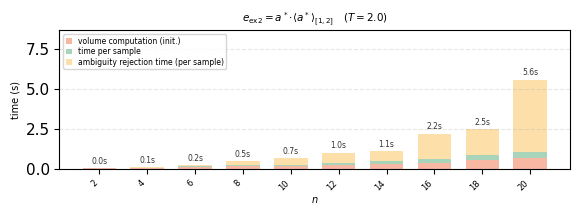

In [11]:
import random
random.seed(42); np.random.seed(42)

LOAD_EX2 = False  # set True to skip sampling and load saved CSV

N_VALUES_EX2 = list(range(2, 21, 2))  # [2,4,...,20], step 2
T_EX2        = 2.0
CSV_EX2      = os.path.join(RESULTS, 'results_ex2.csv')

if LOAD_EX2 and os.path.exists(CSV_EX2):
    N_VALUES_EX2, results_ex2 = load_results_csv(CSV_EX2)
    N_VALUES_EX2 = list(range(2, 21, 2))  # [2,4,...,20], step 2
else:
    results_ex2 = collect_timed(
        phi_ex2, N_VALUES_EX2,
        n_of=lambda n: n, T_of=lambda n: T_EX2,
        label='ex2')
    save_results_csv(CSV_EX2, N_VALUES_EX2, results_ex2)

fig, ax = plt.subplots(figsize=(FIG_W, PANEL_H * 1.2))
stress_bar_plot(ax, N_VALUES_EX2, results_ex2, r'$n$',
                r'$e_{\mathrm{ex2}}=a^*\!\cdot\!\langle a^*\rangle_{[1,2]}\quad(T{=}' + str(T_EX2) + r')$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex2.pdf'), bbox_inches='tight')
plt.show()

## $e_{\mathrm{ex3}} = (\langle aa\rangle_{\leq 1}\cdot a)\cap(a\cdot\langle aa\rangle_{\leq 1})$

$n=3$ fixed, $T\in(0,2)$. Language is empty at $T\geq 2$ (constraint $\tau_2\leq 2-T$).

=== ex3 ===
  n=3  T=0.1  elapsed=0s
    t_vol=0.02s  t_sample/call=0.015s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=3  T=0.25  elapsed=0s
    t_vol=0.02s  t_sample/call=0.009s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=3  T=0.5  elapsed=1s
    t_vol=0.01s  t_sample/call=0.008s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=3  T=0.75  elapsed=1s
    t_vol=0.01s  t_sample/call=0.009s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=3  T=1.0  elapsed=1s
    t_vol=0.01s  t_sample/call=0.010s  s_rej=0.0  i_rej=0.0  ok=20/20
  n=3  T=1.25  elapsed=1s
    t_vol=0.01s  t_sample/call=0.021s  s_rej=0.0  i_rej=1.4  ok=20/20
  n=3  T=1.5  elapsed=2s
    t_vol=0.01s  t_sample/call=0.021s  s_rej=0.0  i_rej=1.6  ok=20/20
  n=3  T=1.75  elapsed=2s
    t_vol=0.01s  t_sample/call=0.159s  s_rej=0.0  i_rej=18.4  ok=20/20
  n=3  T=1.8  elapsed=5s
Did 100 rejections.
Did 100 rejections.
    t_vol=0.01s  t_sample/call=0.383s  s_rej=0.0  i_rej=33.9  ok=20/20
  n=3  T=1.85  elapsed=13s
Did 100 rejections.
Did 100 rejections.
    t_vol=0.02s  t_s

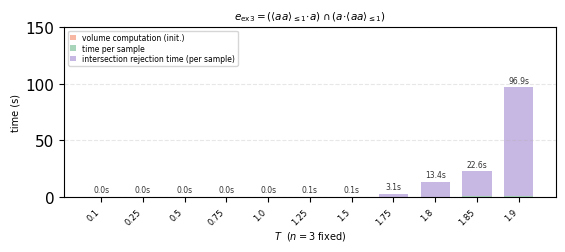

In [17]:
import random
random.seed(42); np.random.seed(42)

LOAD_EX3      = False  # set True to skip sampling and load saved CSV
T_VALUES_EX3  = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.8, 1.85, 1.9]
CSV_EX3       = os.path.join(RESULTS, 'results_ex3.csv')

if LOAD_EX3 and os.path.exists(CSV_EX3):
    T_VALUES_EX3, results_ex3 = load_results_csv(CSV_EX3)
else:
    # phi_ex3 uses intersection — slice_volume not supported at top level, but sub-volumes
    # are precomputed on both arms before sampling so t_vol is recorded correctly.
    # intersect_rej bars grow as T->2 and the intersection language shrinks.
    results_ex3 = collect_timed(
        phi_ex3, T_VALUES_EX3,
        n_of=lambda T: 3, T_of=lambda T: T,
        label='ex3', is_intersection=True)
    save_results_csv(CSV_EX3, T_VALUES_EX3, results_ex3)

fig, ax = plt.subplots(figsize=(FIG_W, PANEL_H * 1.4))
stress_bar_plot(ax, T_VALUES_EX3, results_ex3, r'$T$  ($n=3$ fixed)',
                r'$e_{\mathrm{ex3}}=(\langle aa\rangle_{\leq 1}\!\cdot\! a)'
                r'\cap(a\!\cdot\!\langle aa\rangle_{\leq 1})$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex3.pdf'), bbox_inches='tight')
plt.show()

## $e_{\mathrm{exb}} = \langle b\rangle^*_{[3,4]}\!\cdot\!(\langle a\rangle_{[1,2]}\!\cdot\!\langle b\rangle_{[3,4]}\!\cdot\!\langle b\rangle^*_{[3,4]})^*$

All atoms bounded $\Rightarrow$ finite volume, $T$ auto-sampled. 
At $n\geq 12$ mpmath precision fails (large $T\sim 40$+ triggers same threshold as $e_{\mathrm{ex1}}$).

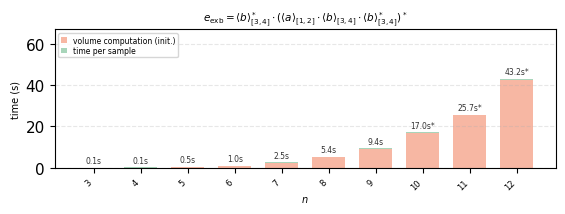

In [13]:
import random
random.seed(42); np.random.seed(42)

LOAD_EXB     = True  # set True to skip sampling and load saved CSV
N_VALUES_EXB = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
CSV_EXB      = os.path.join(RESULTS, 'results_exb.csv')

if LOAD_EXB and os.path.exists(CSV_EXB):
    N_VALUES_EXB, results_exb = load_results_csv(CSV_EXB)
    N_VALUES_EXB = [int(v) for v in N_VALUES_EXB]
else:
    results_exb = collect_timed(
        phi_exb, N_VALUES_EXB,
        n_of=lambda n: n, T_of=lambda n: None,
        label='exb')
    save_results_csv(CSV_EXB, N_VALUES_EXB, results_exb)

fig, ax = plt.subplots(figsize=(FIG_W, PANEL_H * 1.2))
stress_bar_plot(ax, N_VALUES_EXB, results_exb, r'$n$',
                r'$e_{\mathrm{exb}}=\langle b\rangle^*_{[3,4]}\cdot'
                r'(\langle a\rangle_{[1,2]}\cdot\langle b\rangle_{[3,4]}\cdot'
                r'\langle b\rangle^*_{[3,4]})^*$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_exb.pdf'), bbox_inches='tight')
plt.show()

## Combined stress-test figure

All four expressions in one figure. Dashed red line marks the onset of mpmath precision failures.

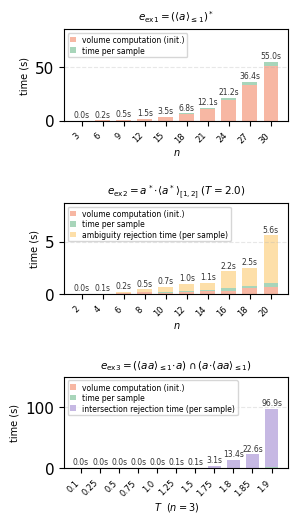

Saved 11_stress_ex123.pdf


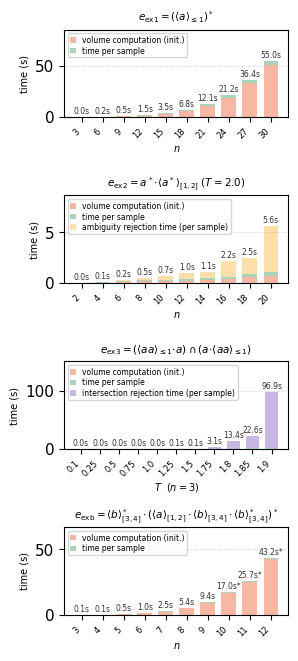

Saved 11_stress_all.pdf


In [18]:
# Run the experiment cells above first so results_ex1..exb are in scope.
# Tip: flip all LOAD_EX* = True above so only this cell needs to run for plot changes.

# ── 3-panel: ex1, ex2, ex3 ────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(COL_W, PANEL_H * 3),
                                     gridspec_kw={'hspace': 0.9})

stress_bar_plot(ax1, N_VALUES_EX1, results_ex1, r'$n$',
                r'$e_{\mathrm{ex1}}=(\langle a\rangle_{\leq 1})^*$')

stress_bar_plot(ax2, N_VALUES_EX2, results_ex2, r'$n$',
                r'$e_{\mathrm{ex2}}=a^*\!\cdot\!\langle a^*\rangle_{[1,2]}\;(T{=}' + str(T_EX2) + r')$')

stress_bar_plot(ax3, T_VALUES_EX3, results_ex3, r'$T$  ($n=3$)',
                r'$e_{\mathrm{ex3}}=(\langle aa\rangle_{\leq 1}\!\cdot\! a)'
                r'\cap(a\!\cdot\!\langle aa\rangle_{\leq 1})$')

fig.savefig(os.path.join(RESULTS, '11_stress_ex123.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved 11_stress_ex123.pdf')

# ── 4-panel: all ──────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(COL_W, PANEL_H * 4),
                                          gridspec_kw={'hspace': 0.9})

stress_bar_plot(ax1, N_VALUES_EX1, results_ex1, r'$n$',
                r'$e_{\mathrm{ex1}}=(\langle a\rangle_{\leq 1})^*$')

stress_bar_plot(ax2, N_VALUES_EX2, results_ex2, r'$n$',
                r'$e_{\mathrm{ex2}}=a^*\!\cdot\!\langle a^*\rangle_{[1,2]}\;(T{=}' + str(T_EX2) + r')$')

stress_bar_plot(ax3, T_VALUES_EX3, results_ex3, r'$T$  ($n=3$)',
                r'$e_{\mathrm{ex3}}=(\langle aa\rangle_{\leq 1}\!\cdot\! a)'
                r'\cap(a\!\cdot\!\langle aa\rangle_{\leq 1})$')

stress_bar_plot(ax4, N_VALUES_EXB, results_exb, r'$n$',
                r'$e_{\mathrm{exb}}=\langle b\rangle^*_{[3,4]}\cdot'
                r'(\langle a\rangle_{[1,2]}\cdot\langle b\rangle_{[3,4]}\cdot\langle b\rangle^*_{[3,4]})^*$')

fig.savefig(os.path.join(RESULTS, '11_stress_all.pdf'), bbox_inches='tight')
plt.show()
print(f'Saved 11_stress_all.pdf')

## Why mpmath fails at large $n$ — a precise account

### The code path

Every time VolTRE samples a duration $T_1$ for a subexpression (e.g. the left branch
of a concatenation), it runs through three steps inside `VolumePoly.inverse_sampling`
(`volume/VolumePoly.py`, line 615):

1. **Build the CDF.** Normalise the volume polynomial $V_n(T)$ by the total volume,
   then integrate symbolically.  The CDF is still a piecewise polynomial with exact
   rational sympy coefficients — no floating-point involved yet.

2. **Find the bracket.** Scan the pieces to locate $[a, b]$ with $\mathrm{CDF}(a) \le u \le \mathrm{CDF}(b)$
   for the drawn $u \sim \mathrm{Uniform}[0,1]$.

3. **Invert via bisection (this is where mpmath enters).**
   ```python
   f_num = sympy.lambdify(T, cdf_piece.as_expr() - u, 'mpmath')
   fa, fb = f_num(a), f_num(b)
   if fa * fb >= 0:
       raise InverseSamplingException(...)   # ← the crash
   root = mp.findroot(f_num, (a, b), solver='bisect')
   ```
   `lambdify(..., 'mpmath')` converts the sympy polynomial into a callable that
   evaluates in **mpmath's current working precision** — by default `mp.dps = 15`,
   i.e. $\approx 50$ bits, the same as `float64`.

---

### Why the sign check fails: catastrophic cancellation

For $e_{\mathrm{ex1}} = (\langle a\rangle_{\leq 1})^*$ the CDF on the piece $[1, 2]$ is
the integral of the PDF, which itself comes from the inclusion-exclusion formula for
the volume of an $n$-simplex restricted to a unit hypercube:

$$V_n(T) = \frac{1}{n!}\sum_{k=0}^{\lfloor T \rfloor}(-1)^k\binom{n}{k}(T-k)^n$$

On the piece $[1, 2]$ (two terms, $k=0$ and $k=1$):

$$V_n(T) = \frac{T^n - n\,(T-1)^n}{n!}$$

Each summand is $O(1)$ in magnitude, but they nearly cancel: the result is
$O(T^n/n!)$ which for $T \approx 1.5$, $n = 22$ is roughly
$1.5^{22}/22! \approx 10^{-15}$.  You are subtracting two numbers of order 1 to
extract a result of order $10^{-15}$ — exactly the noise floor of 15-digit arithmetic.
The polynomial evaluated at floating-point precision has the **wrong sign** with high
probability, so `fa * fb >= 0` triggers and an `InverseSamplingException` is raised.

**Why $n \approx 22$ specifically?** The magnitude of the leading coefficient is
$T^n / n!$.  With $T \sim 1$ we need $n! \lesssim 10^{15}$ (the precision budget) for
reliable evaluation.  $21! \approx 5 \times 10^{19}$ is already too large; in practice
failures start appearing at $n = 20$ (occasional) and are total by $n = 22$.

**Why $n \approx 11$ for $e_{\mathrm{exb}}$?** The bounded intervals $[3,4]$ force
large total durations — at $n = 10$ a typical word has $T \approx 35$.  The
inclusion-exclusion term $(T-k)^n$ with $T - k \sim 35$ gives
$35^{10} \approx 2.8 \times 10^{15}$ even without the factorial.  Combined with the
factorial denominator the coefficients saturate 15-digit precision already at $n \sim 10$–$11$.

---

### Proposed fix

The root cause is a single hard-coded precision.  The fix is to temporarily raise it
around the `findroot` call in `VolumePoly.inverse_sampling`:

```python
# in volume/VolumePoly.py, replace the three lines:
#   fa, fb = f_num(a), f_num(b)
#   if fa * fb >= 0: raise InverseSamplingException(...)
#   root = mp.findroot(f_num, (a, b), solver='bisect')
# with:

_dps = max(mp.dps, 3 * n + 10)   # heuristic: n extra decimal digits
with mp.workdps(_dps):
    fa, fb = f_num(a), f_num(b)
    if fa * fb >= 0:
        raise InverseSamplingException(
            f"Sign check failed: f(a)={fa}, f(b)={fb} on [{a},{b}]"
        )
    root = mp.findroot(f_num, (a, b), solver='bisect')
```

`mp.workdps` is a context manager that temporarily sets precision and restores it on
exit — thread-safe, no global side effects.  The heuristic `3*n + 10` extra decimal
digits is conservative; in practice `n + 20` is already enough for the expressions
in this paper.

**Upsides:**
- Completely eliminates the failure for $e_{\mathrm{ex1}}$ up to $n \approx 50$–$60$
  and for $e_{\mathrm{exb}}$ up to $n \approx 20$–$25$ — well beyond what the paper
  needs.
- The fix is localised to one function; no change to the symbolic volume computation.
- `mp.workdps` is cheap (two integer assignments); overhead is in the evaluation of
  the polynomial at higher precision.

**Downsides:**
- **Slower per sample.** mpmath bisection converges at $O(\log_2(1/\varepsilon))$
  iterations where $\varepsilon$ is the target precision.  Going from 50 bits to
  $\sim 3n$ bits at $n = 22$ means roughly $3 \times$ more iterations, each evaluating
  a degree-$n$ polynomial at higher precision.  Rough slowdown: **$2$–$4\times$ per
  sample** in the failing regime, negligible for small $n$.
- **There is still an asymptotic wall.** For very large $n$ the required precision
  grows linearly in $n$, and mpmath evaluation of an $n$-degree polynomial at
  $p$-bit precision costs $O(n \cdot p)$ bit-operations per polynomial evaluation.
  Bisection needs $O(p)$ iterations.  Total cost per sample is $O(n \cdot p^2)$
  where $p = O(n)$, i.e. $O(n^3)$ — a cube in $n$.  At $n = 100$ this becomes
  noticeable; at $n = 200$ it will be the bottleneck.
- **The heuristic $3n + 10$ is not proven tight.** For expressions with bounded
  intervals and large $T$ (like $e_{\mathrm{exb}}$) you may need more digits; add a
  $+\lceil n \log_{10} T_{\max} \rceil$ term if needed.
